# LightGBM Demo — Pipeline on Concrete Days

A pedagogical companion to `lgbm_explain.ipynb`. Where `lgbm_explain` reports
aggregate CV statistics, this notebook *shows the model at work* on individual
days:

1. **Stage 1 (wet/dry)** — full-grid `p(wet)` heatmap with held-out test
   stations overlaid (predicted vs observed wet/dry side-by-side).
2. **Stage 2 (quantiles)** — 11-quantile predictions on holdout stations for
   one date, with q50 vs truth and per-station 90 % PI bands.
3. **Final composite** — Stage 1 mask × Stage 2 q50 over the full 1 km grid
   plus a 90 % prediction-interval width map (uncertainty).
4. **Multi-resolution sweep** — three dates (heavy / typical / dry) at
   1 km / 2 km / 5 km grid spacing (3 × 3 figure).

The notebook only **inferences** with already-trained artefacts:

- `results/lgbm/stage_1/lgbm_stage1_final.joblib` — Stage 1 classifier
- `results/lgbm/final/models.joblib` — Stage 2 final 11 boosters
- `outputs/holdout_station_ids.json` — 493 holdout station IDs

No retraining, no fold-wise CV. All figures land in `thesis/text/images/05/`.


## 1. Imports & Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

import joblib
from joblib import Parallel, delayed
from sklearn.neighbors import BallTree
import properscoring as ps

warnings.filterwarnings('ignore')

ROOT = Path('../..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)
print(f'CWD: {Path.cwd()}')

from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.transforms import ProjectionTransform, IndicatorTransform
from thesis.transforms.pipeline import TransformPipeline
from thesis.datasets.protocols import PredictionGrid
from thesis.models.grk.features import compute_day_geo_features


CWD: /Users/etomengoi/Desktop/precip_interpolation_thesis


## 2. Constants & Paths

In [2]:
# Single-day demo (Stage 1 / Stage 2 / Final composite)
DEMO_DATE       = '2013-02-01'

# Resolution sweep — one fully-wet day, contrasted at fine vs coarse grid
SWEEP_DATE        = '2013-02-01'                 # whole grid is wet here
SWEEP_RESOLUTIONS = [250, 5000]                  # 20× span, brackets "≤ 1 km" target

# Stage-1 config (must match lgbm_stage1.ipynb)
K_NEIGHBORS_S1  = 50
THRESHOLD_S1    = 0.40           # P(wet) > 0.40 → wet (Hofstra 2008)
STAGE1_FEATS    = ['x_proj', 'y_proj', 'elevation_m',
                   'global_wet_frac', 'knn_wet_frac', 'knn_mean_dist_km']

# Stage-2 config (must match lgbm_train.ipynb)
K_GEO           = 15
SVD_QUANTILES   = np.arange(0.0, 1.05, 0.05)            # 21 svd_*
SVD_COLS        = [f'svd_{i:02d}' for i in range(len(SVD_QUANTILES))]
SOIL_VARS       = ['bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa']
QUANTILES       = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

# Palette (consistent with lgbm_explain.ipynb)
C_LGBM   = '#ff7f0e'
C_IO     = '#FFD580'
C_DATA   = '#B5D4F0'
C_METRIC = '#A8E0A8'

# Paths
RES_DIR    = Path('results/lgbm')
STAGE1_DIR = RES_DIR / 'stage_1'
FINAL_DIR  = RES_DIR / 'final'
DEMO_DIR   = RES_DIR / 'demo'
DEMO_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = Path('thesis/text/images/05')
FIG_DIR.mkdir(parents=True, exist_ok=True)

HOLDOUT_JSON = Path('outputs/holdout_station_ids.json')
HOLDOUT_IDS  = set(json.loads(HOLDOUT_JSON.read_text()))

print(f'DEMO_DATE         = {DEMO_DATE}')
print(f'SWEEP_DATE        = {SWEEP_DATE}')
print(f'SWEEP_RESOLUTIONS = {SWEEP_RESOLUTIONS} m')
print(f'Holdout: {len(HOLDOUT_IDS)} stations')
print(f'Figures → {FIG_DIR}')


DEMO_DATE         = 2013-02-01
SWEEP_DATE        = 2013-02-01
SWEEP_RESOLUTIONS = [250, 5000] m
Holdout: 492 stations
Figures → thesis/text/images/05


## 3. Load Stations (train + holdout)

`exclude_holdout=False` returns every station; we mark the 493 holdout IDs
separately so they can be excluded from the *neighbour pool* used in feature
computation. This is exactly the leakage-free pattern from `lgbm_test.ipynb`.

In [3]:
cfg      = Config()
registry = DataRegistry.from_config(cfg)

print(f'Date range: {cfg.date_start} → {cfg.date_end}')
print('Loading stations (train + holdout)...')

all_raw  = registry.stations.load(cfg.date_start, cfg.date_end, exclude_holdout=False)
pipeline = TransformPipeline([
    ProjectionTransform(target_crs=cfg.study_area.target_crs),
    IndicatorTransform(threshold_mm=cfg.wet_day_threshold_mm),
])
all_proc = pipeline.fit_transform(all_raw)
all_proc['is_holdout'] = all_proc['station_id'].isin(HOLDOUT_IDS)

df_wet = all_proc[all_proc['rain_indicator'] == 1].copy()

station_meta = (
    all_proc
    .drop_duplicates('station_id')[
        ['station_id', 'x_proj', 'y_proj', 'elevation_m', 'is_holdout']
    ].reset_index(drop=True)
)

n_train_st = (~station_meta['is_holdout']).sum()
n_test_st  =  station_meta['is_holdout'].sum()
print(f'Stations: {len(station_meta):,}  (train={n_train_st:,}, holdout={n_test_st:,})')
print(f'Wet records: {len(df_wet):,}')


Date range: 1961-01-01 → 2023-12-31
Loading stations (train + holdout)...
Stations: 2,458  (train=1,966, holdout=492)
Wet records: 21,745,253


## 4. SoilGrids per-station (static covariates)

In [4]:
soil_rows = {'station_id': station_meta['station_id'].values}
for var, src in registry.soilgrids.items():
    if var in SOIL_VARS:
        soil_rows[var] = src.sample_at_projected(
            station_meta['x_proj'].values,
            station_meta['y_proj'].values,
        )
soil_static    = pd.DataFrame(soil_rows).set_index('station_id')
available_soil = [v for v in SOIL_VARS if v in soil_static.columns]
for v in available_soil:
    soil_static[v] = soil_static[v].fillna(float(soil_static[v].median()))

print(f'SoilGrids static: {soil_static.shape}')
print(f'Available: {available_soil}')


SoilGrids static: (2458, 6)
Available: ['bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa']


## 6. Stage 1 — Load Classifier and Pre-compute Station Features

The Stage 1 model is a binary `LGBMClassifier` predicting wet/dry from six
features. We re-build the per-station feature pipeline (global_wet_frac,
knn_wet_frac, knn_mean_dist_km) on **all stations** so we can score the
holdout subset on any date. The KNN tree uses *all* stations as the
neighbour pool — this matches how the final Stage-1 model was trained
(`lgbm_stage1.ipynb` cell 27).

In [5]:
# Load Stage 1 classifier
S1_MODEL = STAGE1_DIR / 'lgbm_stage1_final.joblib'
final_clf = joblib.load(S1_MODEL)
print(f'Stage 1 model:  {S1_MODEL}')
print(f'  num_trees:    {final_clf.booster_.num_trees()}')

# Build per-station Stage-1 features for every (date, station)
print('\nBuilding Stage 1 station features...')
station_meta_all = (
    all_proc
    .drop_duplicates('station_id')[
        ['station_id', 'x_proj', 'y_proj', 'elevation_m']
    ].reset_index(drop=True)
)
station_xy_all = station_meta_all[['x_proj', 'y_proj']].values

gwf_all = (
    all_proc.groupby('date')['rain_indicator']
    .mean().rename('global_wet_frac').reset_index()
)
pivot_all = (
    all_proc[['date', 'station_id', 'rain_indicator']]
    .pivot_table(index='date', columns='station_id', values='rain_indicator', aggfunc='first')
)

tree_all = BallTree(station_xy_all, metric='euclidean')
tr_d, tr_i = tree_all.query(station_xy_all, k=K_NEIGHBORS_S1 + 1)

n_st = len(station_meta_all)
wet_mat_all = np.zeros((n_st, len(pivot_all)), dtype=np.float32)
dist_km_all = np.zeros(n_st, dtype=np.float32)
for i in range(n_st):
    mask    = tr_d[i] > 1.0
    nbr_ids = station_meta_all['station_id'].values[tr_i[i][mask]][:K_NEIGHBORS_S1]
    valid   = [s for s in nbr_ids if s in pivot_all.columns]
    if valid:
        wet_mat_all[i] = pivot_all[valid].mean(axis=1).values
    dist_km_all[i] = tr_d[i][mask][:K_NEIGHBORS_S1].mean() / 1000.0

station_ids_ordered = station_meta_all['station_id'].values
print(f'Station Stage-1 feature stack ready: {n_st} stations × {len(pivot_all)} dates')


Stage 1 model:  results/lgbm/stage_1/lgbm_stage1_final.joblib
  num_trees:    1000

Building Stage 1 station features...
Station Stage-1 feature stack ready: 2458 stations × 23010 dates


## 7. Stage 1 Grid Prediction (parameterised by resolution)

Builds a `PredictionGrid` at the requested resolution and caches its KNN
indices. `predict_grid_stage1(date, res_m)` returns `p_wet` over the grid
plus the holdout station predictions for that date.

In [6]:
def build_grid(res_m: int) -> PredictionGrid:
    cfg_local = Config()
    cfg_local.study_area.grid_resolution_m = res_m
    return PredictionGrid.from_config(cfg_local, dem=registry.dem)

def grid_knn_for(grid: PredictionGrid, res_m: int):
    cache = DEMO_DIR / f'grid_knn_indices_{res_m}m.npz'
    if cache.exists():
        npz = np.load(cache)
        return npz['idxs'], npz['dists']
    print(f'  computing KNN for {grid.n_cells():,} cells at {res_m} m...')
    tree = BallTree(station_xy_all, metric='euclidean')
    dists_m, idxs = tree.query(grid.coords_proj, k=K_NEIGHBORS_S1)
    idxs        = idxs.astype(np.int32)
    dists_km    = (dists_m / 1000.0).astype(np.float32)
    np.savez_compressed(cache, idxs=idxs, dists=dists_km)
    return idxs, dists_km

def predict_grid_stage1(date_str: str, grid: PredictionGrid, res_m: int) -> dict:
    date_str = str(date_str)
    if date_str not in pivot_all.index:
        raise ValueError(f'Date {date_str} not in pivot')

    grid_idxs, grid_dists_km = grid_knn_for(grid, res_m)
    grid_mean_dist_km        = grid_dists_km.mean(axis=1)

    obs_row     = pivot_all.loc[date_str]
    station_obs = obs_row.reindex(station_ids_ordered).fillna(0).values.astype(np.float32)
    gwf_val     = float(np.nanmean(station_obs))

    knn_obs           = station_obs[grid_idxs]
    knn_wet_frac_grid = knn_obs.mean(axis=1)

    H, W      = grid.shape
    gx_flat   = grid.coords_proj[:, 0]
    gy_flat   = grid.coords_proj[:, 1]
    elev_flat = grid.elevation_m.ravel()

    X_grid = np.column_stack([
        gx_flat, gy_flat, elev_flat,
        np.full(len(gx_flat), gwf_val, np.float32),
        knn_wet_frac_grid,
        grid_mean_dist_km,
    ]).astype(np.float32)

    p_wet    = final_clf.predict_proba(X_grid)[:, 1].reshape(H, W)
    wet_grid = p_wet > THRESHOLD_S1

    # Score the same date on holdout stations
    wet_mat_d  = wet_mat_all[:, list(pivot_all.index).index(date_str)]
    X_st = np.column_stack([
        station_xy_all[:, 0],
        station_xy_all[:, 1],
        station_meta_all['elevation_m'].values,
        np.full(n_st, gwf_val, np.float32),
        wet_mat_d,
        dist_km_all,
    ]).astype(np.float32)
    p_wet_st  = final_clf.predict_proba(X_st)[:, 1]
    pred_wet  = p_wet_st > THRESHOLD_S1

    day_df = all_proc[all_proc['date'].astype(str) == date_str].copy()
    day_df = day_df.merge(
        pd.DataFrame({
            'station_id': station_ids_ordered,
            'p_wet':      p_wet_st,
            'pred_wet':   pred_wet.astype(int),
        }),
        on='station_id', how='inner',
    )
    day_df['is_holdout'] = day_df['station_id'].isin(HOLDOUT_IDS)

    return dict(
        p_wet     = p_wet,
        wet_grid  = wet_grid,
        gwf       = gwf_val,
        day_df    = day_df,
        grid      = grid,
        res_m     = res_m,
    )

print('predict_grid_stage1() ready.')


predict_grid_stage1() ready.


## 8. Stage 1 Demo Figure — `DEMO_DATE`

Two panels at 1 km resolution:

- **Left**: full-grid `p(wet)` heatmap with the 0.40 contour drawn explicitly.
  Holdout stations overlaid with edge-colour by **predicted** class.
- **Right**: same grid background, but holdout markers coloured by
  **observed** wet/dry. Eye-ball comparison shows where the classifier
  agrees with truth.

Below the figure: confusion table on the 493 holdout stations for that day.

In [7]:
grid_1km = build_grid(1000)
res_demo = predict_grid_stage1(DEMO_DATE, grid_1km, 1000)

H, W   = res_demo['grid'].shape
day_df = res_demo['day_df']
hold   = day_df[day_df['is_holdout']].copy()
print(f'{DEMO_DATE}: holdout n={len(hold)}  '
      f'predicted-wet={int((hold.pred_wet == 1).sum())}  '
      f'observed-wet={int((hold.rain_indicator == 1).sum())}')

# Confusion on holdout
y_obs  = hold['rain_indicator'].astype(int).values
y_pred = hold['pred_wet'].astype(int).values
TP = int(((y_obs == 1) & (y_pred == 1)).sum())
TN = int(((y_obs == 0) & (y_pred == 0)).sum())
FP = int(((y_obs == 0) & (y_pred == 1)).sum())
FN = int(((y_obs == 1) & (y_pred == 0)).sum())
acc = (TP + TN) / max(TP + TN + FP + FN, 1)
print(f'Holdout confusion: TP={TP}  FP={FP}  TN={TN}  FN={FN}  acc={acc:.3f}')


2013-02-01: holdout n=492  predicted-wet=492  observed-wet=492
Holdout confusion: TP=492  FP=0  TN=0  FN=0  acc=1.000


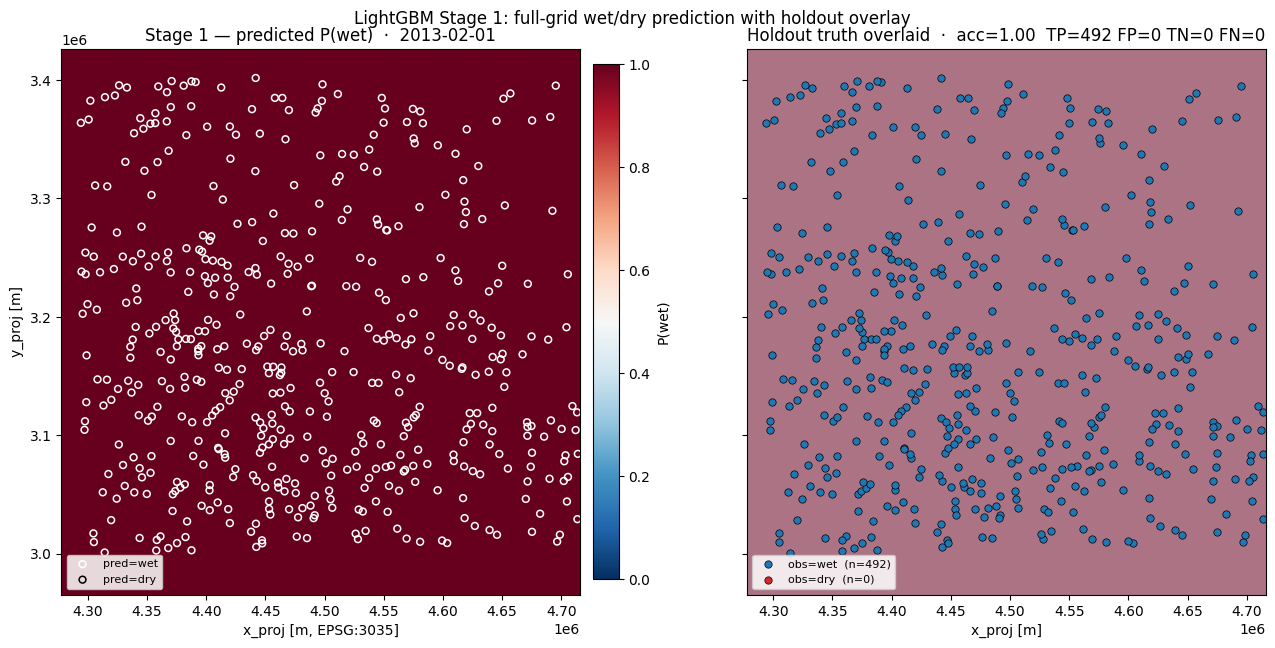

Saved: thesis/text/images/05/lgbm_demo_stage1_2013-02-01.png


In [8]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6.2), constrained_layout=True)

extent_proj = [
    grid_1km.coords_proj[:, 0].min(), grid_1km.coords_proj[:, 0].max(),
    grid_1km.coords_proj[:, 1].min(), grid_1km.coords_proj[:, 1].max(),
]

p_wet = res_demo['p_wet']

# Left — predicted p(wet)
ax = axes[0]
im = ax.imshow(p_wet, origin='lower', extent=extent_proj,
               cmap='RdBu_r', vmin=0, vmax=1, aspect='equal')
ax.contour(p_wet, levels=[THRESHOLD_S1], colors='k',
           linewidths=1.0, linestyles='--',
           extent=extent_proj, origin='lower')
# overlay holdout — coloured by predicted class
for cls, c in [(1, '#ffffff'), (0, '#000000')]:
    sub = hold[hold['pred_wet'] == cls]
    ax.scatter(sub['x_proj'], sub['y_proj'],
               s=24, c='none', edgecolors=c, linewidths=1.1, label=f'pred={"wet" if cls else "dry"}')
ax.set_title(f'Stage 1 — predicted P(wet)  ·  {DEMO_DATE}')
ax.set_xlabel('x_proj [m, EPSG:3035]'); ax.set_ylabel('y_proj [m]')
ax.legend(loc='lower left', fontsize=8, framealpha=0.85)
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='P(wet)')

# Right — same background, markers coloured by observation
ax = axes[1]
ax.imshow(p_wet, origin='lower', extent=extent_proj,
          cmap='RdBu_r', vmin=0, vmax=1, aspect='equal', alpha=0.55)
for cls, c in [(1, '#1f77b4'), (0, '#d62728')]:
    sub = hold[hold['rain_indicator'] == cls]
    ax.scatter(sub['x_proj'], sub['y_proj'],
               s=28, c=c, edgecolors='black', linewidths=0.5,
               label=f'obs={"wet" if cls else "dry"}  (n={len(sub)})')
ax.set_title(f'Holdout truth overlaid  ·  acc={acc:.2f}  TP={TP} FP={FP} TN={TN} FN={FN}')
ax.set_xlabel('x_proj [m]'); ax.set_yticklabels([])
ax.legend(loc='lower left', fontsize=8, framealpha=0.85)

plt.suptitle(f'LightGBM Stage 1: full-grid wet/dry prediction with holdout overlay',
             fontsize=12, y=1.02)
fig_path = FIG_DIR / f'lgbm_demo_stage1_{DEMO_DATE}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')


## 9. Stage 2 — Load Final 11-Quantile Boosters

The Stage 2 model is a dict `{alpha: lgb.Booster}` for the 11 target
quantiles, trained on the **full** non-holdout corpus (no fold split).

In [9]:
saved        = joblib.load(FINAL_DIR / 'models.joblib')
BOOSTERS     = saved['models']
QUANTILES_M  = list(saved['quantiles'])
FEATURE_COLS = list(saved['feature_cols'])
assert QUANTILES_M == QUANTILES, 'quantile order mismatch'
print(f'Stage 2 final model: {len(BOOSTERS)} boosters')
print(f'Feature count:       {len(FEATURE_COLS)}')
print(f'First 6 features:    {FEATURE_COLS[:6]}')


Stage 2 final model: 11 boosters
Feature count:       32
First 6 features:    ['x_proj', 'y_proj', 'elevation_m', 'idw', 'gos', 'svd_00']


## 10. Stage 2 — 11-Quantile Predictions on Holdout for `DEMO_DATE`

For one date we compute the 32-feature vector per holdout-station and then
predict all 11 quantiles. Neighbour pool = non-holdout stations only.

In [10]:
def stage2_features_holdout(date_str: str) -> pd.DataFrame:
    sub = df_wet[df_wet['date'].astype(str) == date_str].copy()
    if not sub['is_holdout'].any():
        return pd.DataFrame()
    train_mask = (~sub['is_holdout'].values)
    recs = compute_day_geo_features(
        date     = date_str,
        xy_all   = sub[['x_proj', 'y_proj']].values,
        z_all    = sub['precip_mm'].values,
        sids_all = sub['station_id'].values,
        train_mask    = train_mask,
        k             = K_GEO,
        svd_quantiles = SVD_QUANTILES,
    )
    df = pd.DataFrame(recs)
    return df[df['station_id'].isin(HOLDOUT_IDS)].reset_index(drop=True)

df_geo_demo = stage2_features_holdout(DEMO_DATE)
print(f'Holdout feature rows for {DEMO_DATE}: {len(df_geo_demo)}')

df_test_demo = (
    df_wet.loc[
        df_wet['is_holdout'] & (df_wet['date'].astype(str) == DEMO_DATE),
        ['station_id', 'date', 'precip_mm', 'x_proj', 'y_proj', 'elevation_m']
    ]
    .merge(df_geo_demo, on=['station_id', 'date'], how='inner')
    .merge(soil_static[available_soil].reset_index(), on='station_id', how='left')
    .reset_index(drop=True)
)
for v in available_soil:
    df_test_demo[v] = df_test_demo[v].fillna(df_test_demo[v].median())

print(f'Holdout test frame: {df_test_demo.shape}')

X_te = np.ascontiguousarray(df_test_demo[FEATURE_COLS].values.astype(np.float32))
y_te = df_test_demo['precip_mm'].values.astype(np.float32)
n, K = len(X_te), len(QUANTILES)

q_preds = np.empty((n, K), dtype=np.float32)
for qi, alpha in enumerate(QUANTILES):
    q_preds[:, qi] = BOOSTERS[alpha].predict(X_te, num_iteration=-1).astype(np.float32)
np.clip(q_preds, 0.0, None, out=q_preds)
q_preds.sort(axis=1)

df_test_demo['q50']   = q_preds[:, QUANTILES.index(0.50)]
df_test_demo['q05']   = q_preds[:, QUANTILES.index(0.05)]
df_test_demo['q95']   = q_preds[:, QUANTILES.index(0.95)]
df_test_demo['error'] = df_test_demo['q50'] - df_test_demo['precip_mm']
df_test_demo['crps']  = ps.crps_ensemble(y_te, q_preds)
df_test_demo['in_pi'] = (
    (df_test_demo['precip_mm'] >= df_test_demo['q05']) &
    (df_test_demo['precip_mm'] <= df_test_demo['q95'])
)

mae   = df_test_demo['error'].abs().mean()
crps  = df_test_demo['crps'].mean()
cover = df_test_demo['in_pi'].mean()
print(f'\nDay {DEMO_DATE}: n={n}  CRPS={crps:.3f}  MAE={mae:.3f} mm  '
      f'90% PI coverage={cover:.2%}')


Holdout feature rows for 2013-02-01: 492
Holdout test frame: (492, 35)

Day 2013-02-01: n=492  CRPS=0.447  MAE=0.553 mm  90% PI coverage=95.12%


## 11. Stage 2 Demo Figure — Predicted vs Observed on Holdout

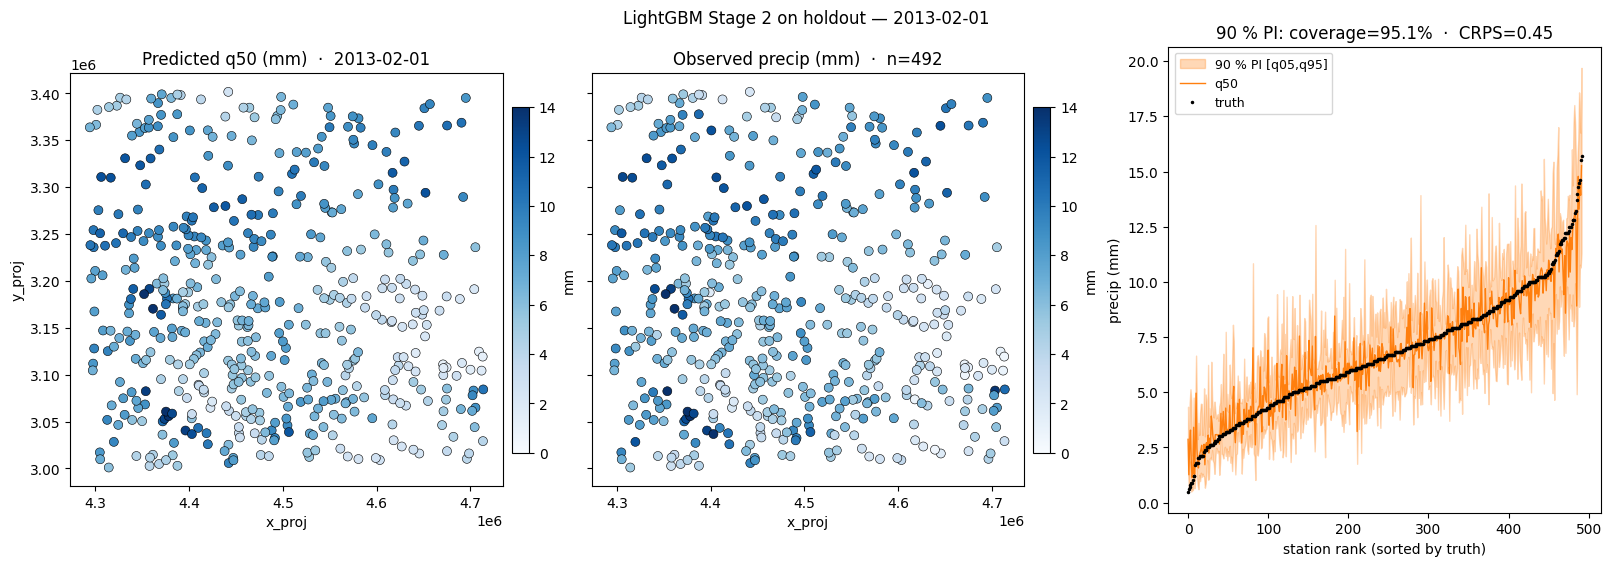

Saved: thesis/text/images/05/lgbm_demo_stage2_2013-02-01.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.4), constrained_layout=True)

vmax = max(df_test_demo['precip_mm'].quantile(0.99),
           df_test_demo['q50'].quantile(0.99), 1.0)

# (a) predicted q50 spatial
ax = axes[0]
sc = ax.scatter(df_test_demo['x_proj'], df_test_demo['y_proj'],
                c=df_test_demo['q50'], cmap='Blues', vmin=0, vmax=vmax,
                s=42, edgecolors='black', linewidths=0.4)
ax.set_title(f'Predicted q50 (mm)  ·  {DEMO_DATE}'); ax.set_aspect('equal')
ax.set_xlabel('x_proj'); ax.set_ylabel('y_proj')
plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02, label='mm')

# (b) observed precip
ax = axes[1]
sc = ax.scatter(df_test_demo['x_proj'], df_test_demo['y_proj'],
                c=df_test_demo['precip_mm'], cmap='Blues', vmin=0, vmax=vmax,
                s=42, edgecolors='black', linewidths=0.4)
ax.set_title(f'Observed precip (mm)  ·  n={len(df_test_demo)}'); ax.set_aspect('equal')
ax.set_xlabel('x_proj'); ax.set_yticklabels([])
plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02, label='mm')

# (c) per-station 90% PI ordered by truth
ax = axes[2]
ord_idx = np.argsort(df_test_demo['precip_mm'].values)
xs      = np.arange(len(ord_idx))
y_tr    = df_test_demo['precip_mm'].values[ord_idx]
y_q05   = df_test_demo['q05'].values[ord_idx]
y_q50   = df_test_demo['q50'].values[ord_idx]
y_q95   = df_test_demo['q95'].values[ord_idx]
ax.fill_between(xs, y_q05, y_q95, color=C_LGBM, alpha=0.30, label='90 % PI [q05,q95]')
ax.plot(xs, y_q50, color=C_LGBM, lw=1.0, label='q50')
ax.plot(xs, y_tr, '.', ms=3, color='black', label='truth')
ax.set_xlabel('station rank (sorted by truth)'); ax.set_ylabel('precip (mm)')
ax.set_title(f'90 % PI: coverage={cover:.1%}  ·  CRPS={crps:.2f}')
ax.legend(loc='upper left', fontsize=9)

plt.suptitle(f'LightGBM Stage 2 on holdout — {DEMO_DATE}', fontsize=12, y=1.02)
fig_path = FIG_DIR / f'lgbm_demo_stage2_{DEMO_DATE}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')


## 12. Stage 2 — Grid Features Helper

For a full-grid quantile prediction we treat every grid cell as a query
point: append `(grid_xy, grid_z=NaN)` to the station array, set
`train_mask = ~is_holdout` (only non-holdout stations may serve as
neighbours), and call the same `compute_day_geo_features`. Output is
cached per `(date, res_m)` — each cache is ≈ 40–80 MB.

In [12]:
def stage2_grid_features(date_str: str, grid: PredictionGrid, res_m: int) -> pd.DataFrame:
    cache = DEMO_DIR / f'stage2_grid_features_{date_str}_{res_m}m.parquet'
    if cache.exists():
        print(f'  [cache] {cache.name}')
        return pd.read_parquet(cache)

    print(f'  computing grid features for {date_str} @ {res_m} m '
          f'({grid.n_cells():,} cells)...')

    # Stations on this date (wet OR dry — wet info is z; classifier gates final pred)
    sub_day = all_proc[all_proc['date'].astype(str) == date_str].copy()
    sub_day = sub_day.dropna(subset=['x_proj', 'y_proj'])

    # We need z = precip_mm; use 0 for stations that report dry (so neighbour
    # pool reflects observed pattern). For grid query we don't supply z.
    sub_day['precip_mm'] = sub_day['precip_mm'].fillna(0.0)

    # Stack stations + grid query points
    n_st_d   = len(sub_day)
    gx       = grid.coords_proj[:, 0]
    gy       = grid.coords_proj[:, 1]
    n_grid   = len(gx)

    xy_all   = np.vstack([sub_day[['x_proj', 'y_proj']].values,
                          np.column_stack([gx, gy])])
    z_all    = np.concatenate([sub_day['precip_mm'].values,
                               np.zeros(n_grid, dtype=np.float64)])  # ignored for grid
    sids_all = np.concatenate([sub_day['station_id'].values.astype(object),
                               np.array([f'_grid_{i}' for i in range(n_grid)], dtype=object)])

    # Train mask: only non-holdout STATIONS may serve as neighbours.
    # Grid cells are query-only (False).
    is_holdout_arr = sub_day['station_id'].isin(HOLDOUT_IDS).values
    train_mask = np.concatenate([~is_holdout_arr, np.zeros(n_grid, dtype=bool)])

    recs = compute_day_geo_features(
        date          = date_str,
        xy_all        = xy_all,
        z_all         = z_all,
        sids_all      = sids_all,
        train_mask    = train_mask,
        k             = K_GEO,
        svd_quantiles = SVD_QUANTILES,
    )
    df_recs = pd.DataFrame(recs)
    df_recs = df_recs[df_recs['station_id'].astype(str).str.startswith('_grid_')].copy()
    df_recs['cell_idx'] = df_recs['station_id'].str.replace('_grid_', '').astype(int)
    df_recs = df_recs.sort_values('cell_idx').reset_index(drop=True)

    df_recs['x_proj']      = gx[df_recs['cell_idx'].values]
    df_recs['y_proj']      = gy[df_recs['cell_idx'].values]
    df_recs['elevation_m'] = grid.elevation_m.ravel()[df_recs['cell_idx'].values]

    # SoilGrids per grid cell
    for var, src in registry.soilgrids.items():
        if var in SOIL_VARS:
            df_recs[var] = src.sample_at_projected(
                df_recs['x_proj'].values, df_recs['y_proj'].values,
            )
    for v in SOIL_VARS:
        if v in df_recs.columns:
            df_recs[v] = df_recs[v].fillna(float(np.nanmedian(df_recs[v].values)))

    df_recs.to_parquet(cache, index=False)
    print(f'  saved cache: {cache} ({cache.stat().st_size / 1e6:.1f} MB)')
    return df_recs

print('stage2_grid_features() ready.')


stage2_grid_features() ready.


## 13. Final Composite — Stage 1 Mask × Stage 2 q50 (full grid)

`precip_pred = where(p_wet < 0.40, 0, q50)`. The right-panel uncertainty map
is `q95 − q05` — the 90 % prediction-interval width.

In [13]:
df_g = stage2_grid_features(DEMO_DATE, grid_1km, 1000)

# Drop cells that lost SoilGrids/elevation (off-domain) — set to 0
keep = df_g[FEATURE_COLS].notna().all(axis=1)
print(f'Keep {keep.sum():,}/{len(df_g):,} grid cells with complete features')

X_g = np.ascontiguousarray(df_g.loc[keep, FEATURE_COLS].values.astype(np.float32))
n_g = len(X_g)

q_g = np.empty((n_g, len(QUANTILES)), dtype=np.float32)
for qi, alpha in enumerate(QUANTILES):
    q_g[:, qi] = BOOSTERS[alpha].predict(X_g, num_iteration=-1).astype(np.float32)
np.clip(q_g, 0.0, None, out=q_g)
q_g.sort(axis=1)

H, W = grid_1km.shape
q50_grid = np.full(H * W, np.nan, dtype=np.float32)
q05_grid = np.full(H * W, np.nan, dtype=np.float32)
q95_grid = np.full(H * W, np.nan, dtype=np.float32)
cell_idx = df_g.loc[keep, 'cell_idx'].values
q50_grid[cell_idx] = q_g[:, QUANTILES.index(0.50)]
q05_grid[cell_idx] = q_g[:, QUANTILES.index(0.05)]
q95_grid[cell_idx] = q_g[:, QUANTILES.index(0.95)]
q50_grid = q50_grid.reshape(H, W)
piw_grid = (q95_grid - q05_grid).reshape(H, W)

p_wet_grid = res_demo['p_wet']
final_grid = np.where(p_wet_grid < THRESHOLD_S1, 0.0, q50_grid)
print(f'Final grid stats: mean={np.nanmean(final_grid):.2f}  '
      f'max={np.nanmax(final_grid):.2f}  wet-cells={(final_grid > 0.5).mean():.1%}')


  [cache] stage2_grid_features_2013-02-01_1000m.parquet
Keep 202,818/202,818 grid cells with complete features
Final grid stats: mean=6.91  max=17.03  wet-cells=100.0%


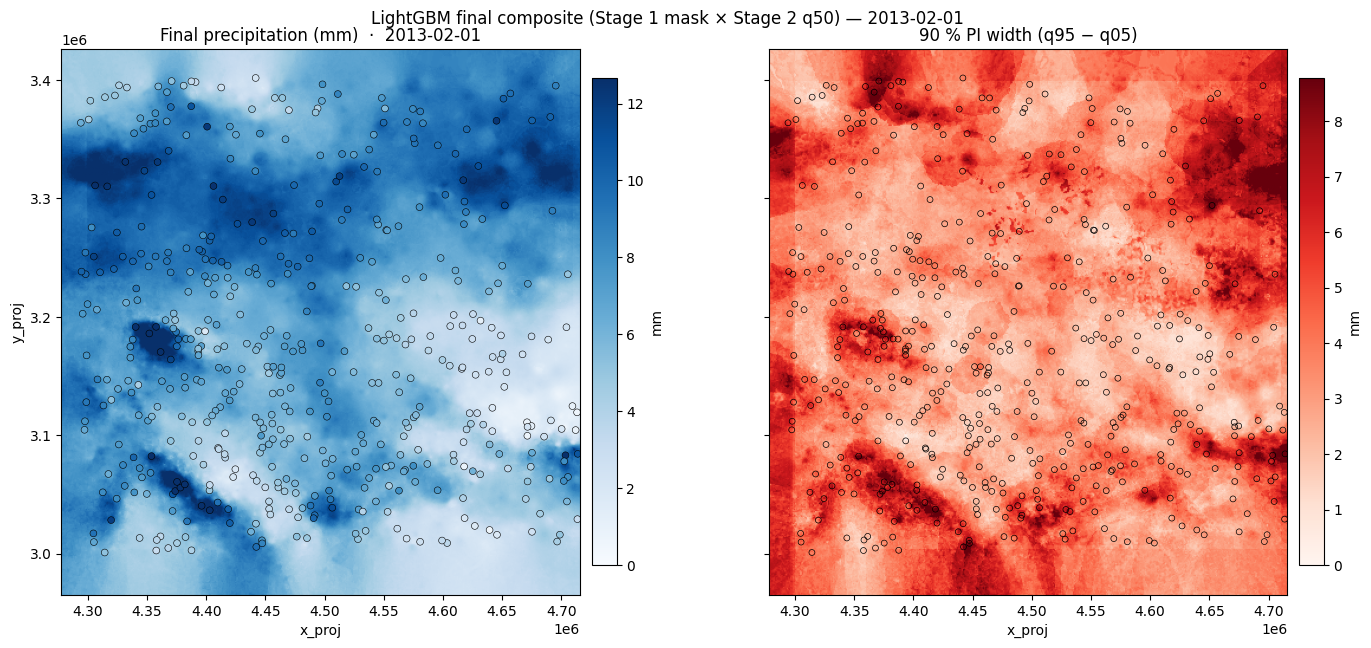

Saved: thesis/text/images/05/lgbm_demo_final_2013-02-01.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.2), constrained_layout=True)

vmax_p = max(np.nanquantile(final_grid, 0.99), 1.0)
vmax_u = max(np.nanquantile(piw_grid,    0.99), 1.0)

# Left — composite precipitation
ax = axes[0]
im = ax.imshow(final_grid, origin='lower', extent=extent_proj,
               cmap='Blues', vmin=0, vmax=vmax_p, aspect='equal')
hold_obs = day_df[day_df['is_holdout']].copy()
ax.scatter(hold_obs['x_proj'], hold_obs['y_proj'],
           c=hold_obs['precip_mm'], cmap='Blues', vmin=0, vmax=vmax_p,
           s=24, edgecolors='black', linewidths=0.4)
ax.set_title(f'Final precipitation (mm)  ·  {DEMO_DATE}')
ax.set_xlabel('x_proj'); ax.set_ylabel('y_proj')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='mm')

# Right — uncertainty (q95 - q05)
ax = axes[1]
im = ax.imshow(piw_grid, origin='lower', extent=extent_proj,
               cmap='Reds', vmin=0, vmax=vmax_u, aspect='equal')
ax.scatter(hold_obs['x_proj'], hold_obs['y_proj'],
           c='none', edgecolors='black', linewidths=0.5, s=18)
ax.set_title('90 % PI width (q95 − q05)')
ax.set_xlabel('x_proj'); ax.set_yticklabels([])
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='mm')

plt.suptitle(f'LightGBM final composite (Stage 1 mask × Stage 2 q50) — {DEMO_DATE}',
             fontsize=12, y=1.02)
fig_path = FIG_DIR / f'lgbm_demo_final_{DEMO_DATE}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')


## 14. Resolution Sweep — 250 m vs 5 km on a Fully-Wet Day

Per assignment §5–6: produce gridded products at *different spatial
resolutions* (≤ 1 km) and discuss them. To make the contrast visible we
pick **one fully-wet day** (`2013-02-01`, every grid cell has Stage-1
`p(wet) > 0.40`) and predict at **250 m** and **5 km** — a 20× span.

What changes between the two:

- **`x_proj, y_proj`** — denser query lattice (3.2 M vs 8 k cells).
- **`elevation_m`** — bilinearly interpolated from native ~30 m DEM at the
  cell centre. At 250 m we sample close to native; at 5 km we drop most of
  the terrain detail.
- **SoilGrids** — native 250 m; sampled at the cell centre. At 5 km grid
  we read one of every ~400 native pixels.
- **`idw, gos, svd_*`** — driven by the K = 15 nearest *stations*, not
  grid cells. Only the slight shift of cell centre relative to the
  station network changes these. Effect is small.

So the difference between 250 m and 5 km is **almost entirely** carried by
DEM + SoilGrids — exactly the auxiliary-data discussion the assignment
asks for. Compute scales with cell count; expect ~10 min for the 250 m
feature pass on this single day.

In [15]:
# Resolution sweep: one fully-wet day, two resolutions
SWEEP_DATE        = '2013-02-01'                 # whole grid is wet here
SWEEP_RESOLUTIONS = [250, 5000]

def composite_for(date_str: str, res_m: int) -> dict:
    grid_r = build_grid(res_m)
    s1     = predict_grid_stage1(date_str, grid_r, res_m)

    df_g   = stage2_grid_features(date_str, grid_r, res_m)
    keep   = df_g[FEATURE_COLS].notna().all(axis=1)
    X_g    = np.ascontiguousarray(df_g.loc[keep, FEATURE_COLS].values.astype(np.float32))

    q_g    = np.empty((len(X_g), len(QUANTILES)), dtype=np.float32)
    for qi, alpha in enumerate(QUANTILES):
        q_g[:, qi] = BOOSTERS[alpha].predict(X_g, num_iteration=-1).astype(np.float32)
    np.clip(q_g, 0.0, None, out=q_g)
    q_g.sort(axis=1)

    H, W   = grid_r.shape
    q50    = np.full(H * W, np.nan, dtype=np.float32)
    q50[df_g.loc[keep, 'cell_idx'].values] = q_g[:, QUANTILES.index(0.50)]
    q50    = q50.reshape(H, W)

    final  = np.where(s1['p_wet'] < THRESHOLD_S1, 0.0, q50)

    return dict(grid=grid_r, final=final, p_wet=s1['p_wet'],
                date=date_str, res_m=res_m, n_cells=int(grid_r.n_cells()))

results_sweep = {}
runtimes      = {}
for r in SWEEP_RESOLUTIONS:
    t0 = time.time()
    results_sweep[r] = composite_for(SWEEP_DATE, r)
    runtimes[r]      = time.time() - t0
    print(f'  {SWEEP_DATE}  @ {r:>5d} m  '
          f'({results_sweep[r]["n_cells"]:>10,} cells)  →  {runtimes[r]:6.1f} s')


  computing KNN for 3,234,285 cells at 250 m...
  computing grid features for 2013-02-01 @ 250 m (3,234,285 cells)...
  saved cache: results/lgbm/demo/stage2_grid_features_2013-02-01_250m.parquet (180.8 MB)
  2013-02-01  @   250 m  ( 3,234,285 cells)  →  1926.8 s
  [cache] stage2_grid_features_2013-02-01_5000m.parquet
  2013-02-01  @  5000 m  (     8,184 cells)  →     3.0 s


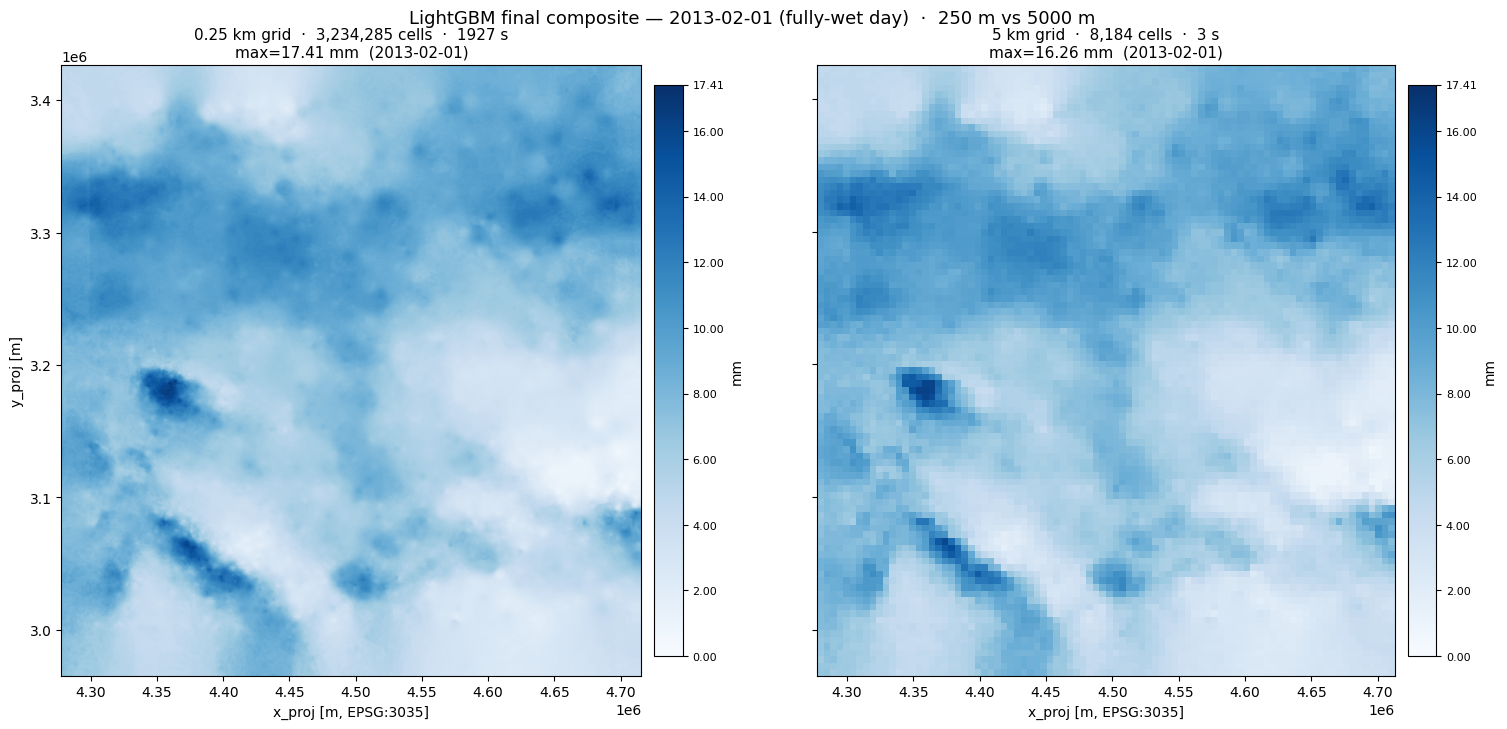

Saved: thesis/text/images/05/lgbm_demo_multires.png

Resolution sweep summary:
 resolution_m   cells  runtime_s  max_mm  mean_mm  std_mm
          250 3234285     1926.8  17.413    6.915   2.658
         5000    8184        3.0  16.255    6.906   2.653


In [16]:
fig, axes = plt.subplots(1, len(SWEEP_RESOLUTIONS),
                         figsize=(7.5 * len(SWEEP_RESOLUTIONS), 7),
                         constrained_layout=True)
if len(SWEEP_RESOLUTIONS) == 1:
    axes = [axes]

# Shared colour scale = nanmax across resolutions, so the deepest blue
# represents the same mm value in both panels and the colourbar exposes
# the actual cap.
row_max = max(float(np.nanmax(results_sweep[r]['final'])) for r in SWEEP_RESOLUTIONS)
row_max = max(row_max, 1.0)

for ax, r in zip(axes, SWEEP_RESOLUTIONS):
    res = results_sweep[r]
    ext = [
        res['grid'].coords_proj[:, 0].min(), res['grid'].coords_proj[:, 0].max(),
        res['grid'].coords_proj[:, 1].min(), res['grid'].coords_proj[:, 1].max(),
    ]
    cell_max = float(np.nanmax(res['final']))
    im = ax.imshow(res['final'], origin='lower', extent=ext,
                   cmap='Blues', vmin=0, vmax=row_max, aspect='equal')
    ax.set_title(
        f'{r/1000:g} km grid  ·  {res["n_cells"]:,} cells  ·  '
        f'{runtimes[r]:.0f} s\nmax={cell_max:.2f} mm  ({SWEEP_DATE})',
        fontsize=11,
    )
    ax.set_xlabel('x_proj [m, EPSG:3035]')
    ax.set_ylabel('y_proj [m]' if r == SWEEP_RESOLUTIONS[0] else '')
    if r != SWEEP_RESOLUTIONS[0]:
        ax.set_yticklabels([])

    cb = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.02, label='mm')
    ticks = list(cb.get_ticks())
    if not any(abs(t - row_max) < 1e-3 for t in ticks):
        ticks = [t for t in ticks if t < row_max - 0.01 * row_max] + [row_max]
        cb.set_ticks(ticks)
    cb.ax.tick_params(labelsize=8)

plt.suptitle(
    f'LightGBM final composite — {SWEEP_DATE} (fully-wet day)  ·  '
    f'{SWEEP_RESOLUTIONS[0]} m vs {SWEEP_RESOLUTIONS[-1]} m',
    fontsize=13, y=1.02,
)
fig_path = FIG_DIR / 'lgbm_demo_multires.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

# Summary table
summary = pd.DataFrame([
    dict(
        resolution_m = r,
        cells        = results_sweep[r]['n_cells'],
        runtime_s    = round(runtimes[r], 1),
        max_mm       = round(float(np.nanmax(results_sweep[r]['final'])), 3),
        mean_mm      = round(float(np.nanmean(results_sweep[r]['final'])), 3),
        std_mm       = round(float(np.nanstd(results_sweep[r]['final'])), 3),
    )
    for r in SWEEP_RESOLUTIONS
])
print('\nResolution sweep summary:')
print(summary.to_string(index=False))


## 14b. Ground-truth Observations for `SWEEP_DATE`

The figure above is a model output. The figure below plots the *raw
station observations* on the same date — every station with a valid
`precip_mm` reading. Same colour scale as §14, so dot intensity matches
the corresponding pixel intensity.

This is the side-by-side baseline for visual comparison: §14 ←→ this
panel, same day, same colourbar.

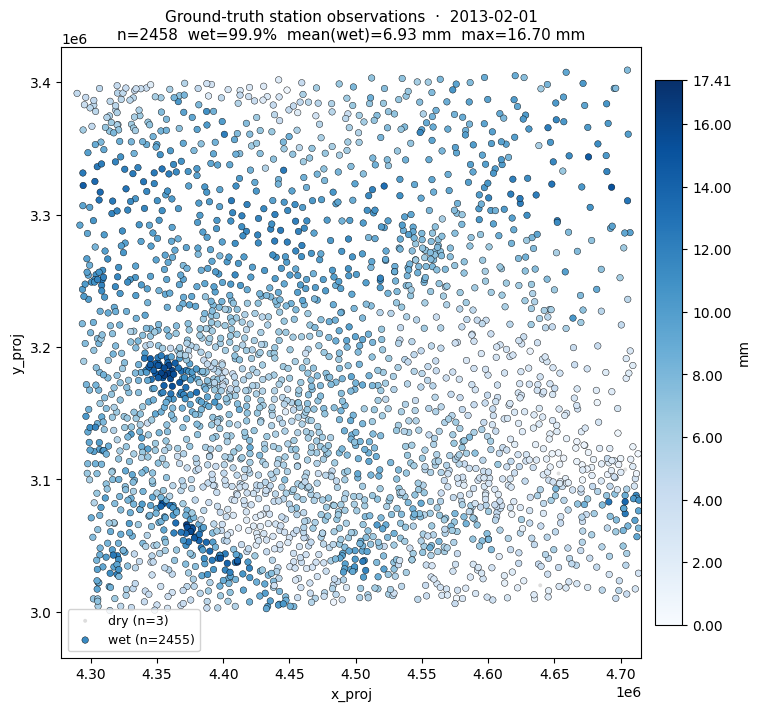

Saved: thesis/text/images/05/lgbm_demo_observations.png

Observations: n=2458  wet%=99.9%  mean(wet)=6.93 mm  max=16.70 mm


In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8, 7), constrained_layout=True)

ext_x = [grid_1km.coords_proj[:, 0].min(), grid_1km.coords_proj[:, 0].max()]
ext_y = [grid_1km.coords_proj[:, 1].min(), grid_1km.coords_proj[:, 1].max()]

sub = all_proc[all_proc['date'].astype(str) == SWEEP_DATE].copy()
sub = sub.dropna(subset=['x_proj', 'y_proj', 'precip_mm'])

n_st_d   = len(sub)
wet_st   = sub[sub['precip_mm'] > 0.5]
wet_frac = len(wet_st) / max(n_st_d, 1)
mean_wet = wet_st['precip_mm'].mean() if len(wet_st) else 0.0
max_obs  = sub['precip_mm'].max() if n_st_d else 0.0

# Match §14 colour scale exactly
vmax_obs = row_max

dry_st = sub[sub['precip_mm'] <= 0.5]
ax.scatter(dry_st['x_proj'], dry_st['y_proj'],
           s=8, c='#dddddd', edgecolors='none',
           label=f'dry (n={len(dry_st)})')

sc = ax.scatter(wet_st['x_proj'], wet_st['y_proj'],
                c=wet_st['precip_mm'], cmap='Blues',
                vmin=0, vmax=vmax_obs,
                s=22, edgecolors='black', linewidths=0.3,
                label=f'wet (n={len(wet_st)})')

ax.set_xlim(ext_x); ax.set_ylim(ext_y); ax.set_aspect('equal')
ax.set_title(
    f'Ground-truth station observations  ·  {SWEEP_DATE}\n'
    f'n={n_st_d}  wet={wet_frac:.1%}  '
    f'mean(wet)={mean_wet:.2f} mm  max={max_obs:.2f} mm',
    fontsize=11,
)
ax.set_xlabel('x_proj'); ax.set_ylabel('y_proj')
ax.legend(loc='lower left', fontsize=9, framealpha=0.85)

cb = plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02, label='mm')
ticks = list(cb.get_ticks())
if not any(abs(t - vmax_obs) < 1e-3 for t in ticks):
    ticks = [t for t in ticks if t < vmax_obs - 0.01 * vmax_obs] + [vmax_obs]
    cb.set_ticks(ticks)

fig_path = FIG_DIR / 'lgbm_demo_observations.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

print(f'\nObservations: n={n_st_d}  wet%={wet_frac:.1%}  '
      f'mean(wet)={mean_wet:.2f} mm  max={max_obs:.2f} mm')


## 15. Summary

Figures produced in `thesis/text/images/05/`:

| File                                      | Section in thesis                  |
| ----------------------------------------- | ---------------------------------- |
| `lgbm_demo_stage1_<DEMO_DATE>.png`        | §5.x — Stage 1 wet/dry demo        |
| `lgbm_demo_stage2_<DEMO_DATE>.png`        | §5.x — Stage 2 quantile demo       |
| `lgbm_demo_final_<DEMO_DATE>.png`         | §5.x — Final composite             |
| `lgbm_demo_multires.png`                  | §5.x — Resolution sensitivity      |
| `lgbm_demo_observations.png`              | §5.x — Ground-truth station obs    |

Caches in `results/lgbm/demo/` (re-runs are cheap):

- `grid_knn_indices_<res>m.npz`
- `stage2_grid_features_<date>_<res>m.parquet`

Companion: `notebooks/04_lgbm/lgbm_explain.ipynb` — aggregate CV statistics,
five-fold metrics audit, and feature importance.